In [1]:
import pandas as pd

df = pd.read_csv('c:/data/ozone/ozone2.csv')
df.head()

,Month,Day,Solar.R,Wind,Temp,Ozone,Result
0,5,1,190.000000,7.4,67,41,0
1,5,2,118.000000,8.0,72,36,0
2,5,3,149.000000,12.6,74,12,0
3,5,4,313.000000,11.5,62,18,0
4,5,5,185.931507,14.3,56,42,1


In [2]:
df.columns

Index(['Month', 'Day', 'Solar.R', 'Wind', 'Temp', 'Ozone', 'Result'], dtype='object')

In [3]:
cols=['Solar.R', 'Wind', 'Temp']
X = df[cols]
y = df['Result']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10, stratify=y)

Text(0, 0.5, 'Inertia')

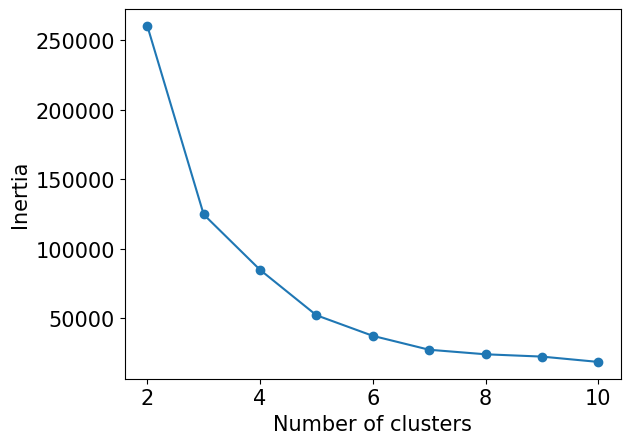

In [5]:
#최적의 클러스터 개수를 구하는 방법
#inertia value : 군집화가 된 후 각 중심점에서 군집의 데이터간의 거리를 합산한 값->작은수록 응집도가 높은 군집
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
clusters = range(2,11)
inertias=[]
for n in clusters:
    model = KMeans(n_clusters=n, random_state=10)
    model.fit(X_train)
    inertias.append(model.inertia_)

plt.rcParams['font.size']=15
plt.plot(clusters, inertias, '-o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [6]:
#엘보우(elbow) 기법
#inertias 값이 하강하다가 팔꿈치처럼 꺾이는 부분 3

In [7]:
model = KMeans(n_clusters=3, random_state=10)
print(model)

KMeans(n_clusters=3, random_state=10)


In [8]:
pred = model.fit_predict(X_train)
print(pred[:5])
pred = model.predict(X_test)
print(pred[:5])

[1 2 0 2 0]
[0 0 1 0 2]


In [ ]:
#군집화에서는 개별 라벨값보다는 군집이 중요함
#실루엣 값은 한 클러스터 안의 데이터들이 다른 클러스터와 비교해서 얼마나 비슷한가를 나타냄
# 실루엣계수가 클수록 좋은 모형

In [9]:
from sklearn.metrics import silhouette_score
silhouette_score(X_test, pred)

0.5558953549067654

In [10]:
model = KMeans(n_clusters=2, random_state=10)
print(model)
pred = model.fit_predict(X_train)
print(pred[:5])
pred = model.predict(X_test)
print(pred[:5])

KMeans(n_clusters=2, random_state=10)
[1 0 0 0 0]
[0 0 1 0 0]


In [11]:
silhouette_score(X_test, pred)

0.6729790456272987

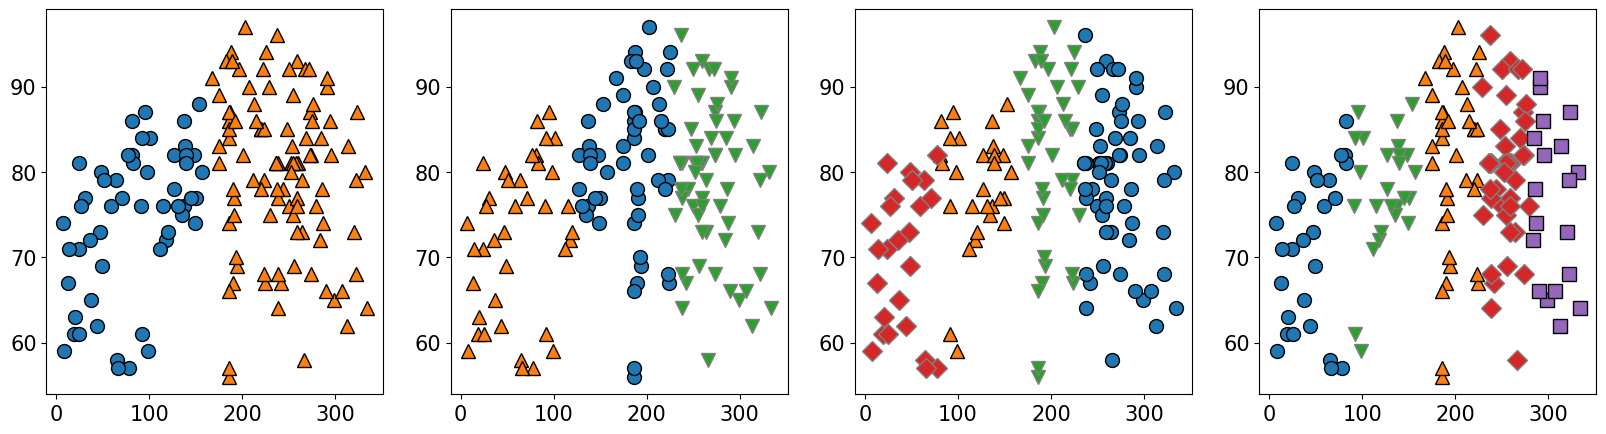

In [12]:
from matplotlib import pyplot as plt
import mglearn

fig,axes = plt.subplots(1,4,figsize=(20,5))

idx=0
for k in [2,3,4,5]:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    lbls = kmeans.labels_
    mglearn.discrete_scatter(X['Solar.R'], X['Temp'], lbls, ax=axes[idx])
    idx+=1